# Cherimoya v0.0.1 vs Cherimoya v0.1.0: profile JSD and log-counts Pearson comparison

Compares two genome-wide benchmark metrics between different versions of Cherimoya models and training loops across all ENCODE PRO-cap atlas experiments:

- **Profile JSD** — Jensen-Shannon distance between predicted and observed read profiles across peak loci. Lower is better (0 = perfect, 1 = maximally wrong).
- **Log-counts Pearson** — Pearson correlation between log-predicted and log-observed total read counts per peak. Higher is better.

Metrics are taken from the `genome_wide` field of each per-experiment benchmark JSON, which aggregates predictions across all 7 held-out test chromosome folds.

In [2]:
import numpy as np
import pandas as pd
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt

## Load data

Both TSVs are generated by consolidating per-experiment benchmark JSONs:
- `performance_metrics/cherimoya_old/procap-atlas_performance_metrics.tsv`
- `performance_metrics/cherimoya/procap-atlas_performance_metrics.tsv` (generated by `src/cherimoya/benchmark/consolidate_metrics.py`)

Only experiments present in both TSVs are included.

In [5]:
cherimoya_old = pd.read_csv("../performance_metrics/cherimoya/v0.0.1/procap-atlas_performance_metrics.tsv", sep="\t")
cherimoya = pd.read_csv("../performance_metrics/cherimoya/procap-atlas_performance_metrics.tsv", sep="\t")

# Inner join: keeps only experiments benchmarked for both models
df = cherimoya_old[["experiment", "biosample", "total_reads", "profile_jsd", "log_counts_pearson"]].merge(
    cherimoya[["experiment", "profile_jsd", "log_counts_pearson"]],
    on="experiment",
    suffixes=("_cherimoya_old", "_cherimoya"),
)
# Positive delta_jsd = Cherimoya is worse; negative = Cherimoya is better
df["delta_jsd"] = df["profile_jsd_cherimoya"] - df["profile_jsd_cherimoya_old"]
# Positive delta_pearson = Cherimoya is better; negative = Cherimoya is worse
df["delta_pearson"] = df["log_counts_pearson_cherimoya"] - df["log_counts_pearson_cherimoya_old"]

print(f"{len(df)} experiments")
df.head()

224 experiments


,experiment,biosample,total_reads,profile_jsd_cherimoya_old,log_counts_pearson_cherimoya_old,profile_jsd_cherimoya,log_counts_pearson_cherimoya,delta_jsd,delta_pearson
0,ENCSR882DWM,K562,27919281,0.435978,0.150124,0.421935,0.163925,-0.014044,0.013801
1,ENCSR114HGS,K562,27605484,0.437573,0.198127,0.430055,0.184103,-0.007518,-0.014024
2,ENCSR165QKR,HCT116,46281192,0.261790,0.742962,0.258108,0.752856,-0.003682,0.009894
3,ENCSR197JLW,HCT116,24514364,0.301987,0.703002,0.316867,0.697371,0.014880,-0.005631
4,ENCSR100EDZ,HCT116,33169222,0.276264,0.773286,0.276910,0.783540,0.000646,0.010254


## Profile JSD

Each point is one experiment. Points **below** the diagonal indicate experiments where Cherimoya achieves lower (better) JSD than cherimoya_old. Points are colored by read depth to show whether improvements are concentrated in well-covered experiments.

The Wilcoxon signed-rank test assesses whether the JSD values are systematically different between the two models across all experiments.

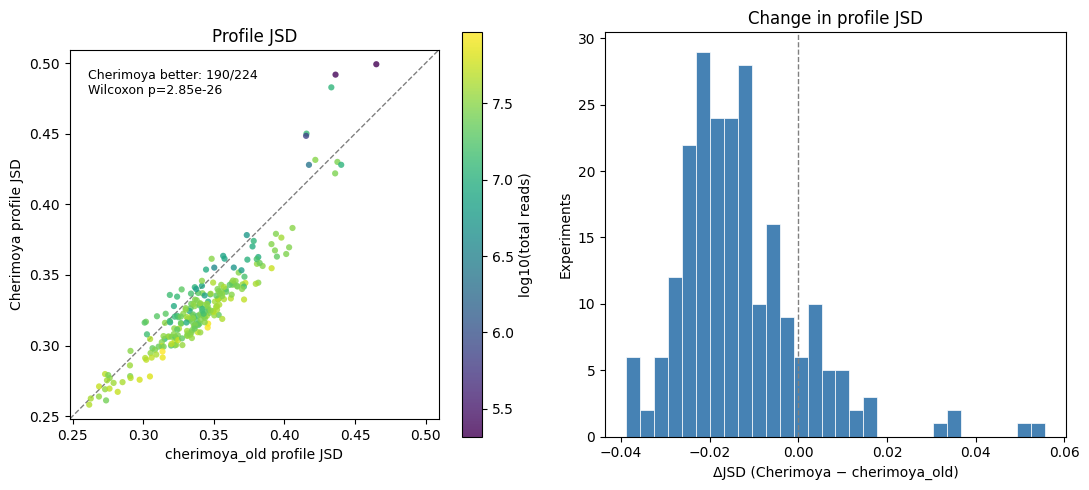

Median ΔJSD: -0.0154
Mean ΔJSD:   -0.0130


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# --- Scatter ---
ax = axes[0]
sc = ax.scatter(
    df["profile_jsd_cherimoya_old"],
    df["profile_jsd_cherimoya"],
    c=np.log10(df["total_reads"]),
    cmap="viridis",
    s=20,
    alpha=0.8,
    linewidths=0,
)
plt.colorbar(sc, ax=ax, label="log10(total reads)")

# Diagonal reference line (y = x): points below = Cherimoya better
lims = [
    min(df["profile_jsd_cherimoya_old"].min(), df["profile_jsd_cherimoya"].min()) - 0.01,
    max(df["profile_jsd_cherimoya_old"].max(), df["profile_jsd_cherimoya"].max()) + 0.01,
]
ax.plot(lims, lims, color="gray", linestyle="dashed", linewidth=1, zorder=0)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_xlabel("cherimoya_old profile JSD")
ax.set_ylabel("Cherimoya profile JSD")
ax.set_title("Profile JSD")

stat, pval = wilcoxon(df["profile_jsd_cherimoya_old"], df["profile_jsd_cherimoya"])
n_better = (df["delta_jsd"] < 0).sum()
ax.text(
    0.05, 0.95,
    f"Cherimoya better: {n_better}/{len(df)}\nWilcoxon p={pval:.2e}",
    transform=ax.transAxes, va="top", fontsize=9,
)

# --- Histogram of deltas ---
ax = axes[1]
ax.axvline(0, color="gray", linestyle="dashed", linewidth=1)
ax.hist(df["delta_jsd"], bins=30, color="steelblue", edgecolor="white", linewidth=0.5)
ax.set_xlabel("ΔJSD (Cherimoya − cherimoya_old)")
ax.set_ylabel("Experiments")
ax.set_title("Change in profile JSD")

fig.tight_layout()
fig.savefig("cherimoya_old_vs_cherimoya_jsd.pdf", dpi=150)
plt.show()

print(f"Median ΔJSD: {df['delta_jsd'].median():.4f}")
print(f"Mean ΔJSD:   {df['delta_jsd'].mean():.4f}")

## Log-counts Pearson

Each point is one experiment. Points **above** the diagonal indicate experiments where Cherimoya achieves higher (better) log-counts Pearson than cherimoya_old. Points are colored by read depth.

The Wilcoxon signed-rank test assesses whether the correlations are systematically different between the two models.

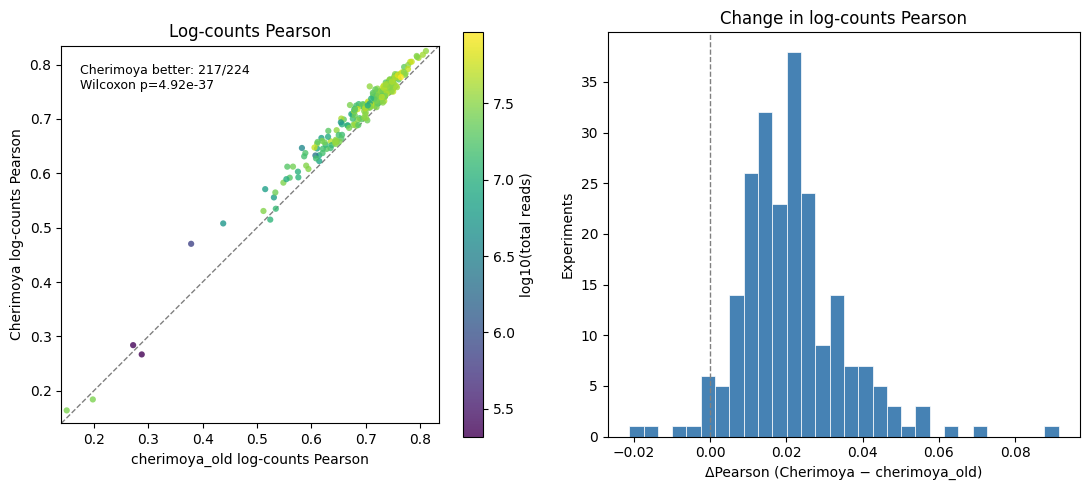

Median ΔPearson: 0.0202
Mean ΔPearson:   0.0210


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# --- Scatter ---
ax = axes[0]
sc = ax.scatter(
    df["log_counts_pearson_cherimoya_old"],
    df["log_counts_pearson_cherimoya"],
    c=np.log10(df["total_reads"]),
    cmap="viridis",
    s=20,
    alpha=0.8,
    linewidths=0,
)
plt.colorbar(sc, ax=ax, label="log10(total reads)")

# Diagonal reference line (y = x): points above = Cherimoya better
lims = [
    min(df["log_counts_pearson_cherimoya_old"].min(), df["log_counts_pearson_cherimoya"].min()) - 0.01,
    max(df["log_counts_pearson_cherimoya_old"].max(), df["log_counts_pearson_cherimoya"].max()) + 0.01,
]
ax.plot(lims, lims, color="gray", linestyle="dashed", linewidth=1, zorder=0)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.set_xlabel("cherimoya_old log-counts Pearson")
ax.set_ylabel("Cherimoya log-counts Pearson")
ax.set_title("Log-counts Pearson")

stat, pval = wilcoxon(df["log_counts_pearson_cherimoya_old"], df["log_counts_pearson_cherimoya"])
n_better = (df["delta_pearson"] > 0).sum()
ax.text(
    0.05, 0.95,
    f"Cherimoya better: {n_better}/{len(df)}\nWilcoxon p={pval:.2e}",
    transform=ax.transAxes, va="top", fontsize=9,
)

# --- Histogram of deltas ---
ax = axes[1]
ax.axvline(0, color="gray", linestyle="dashed", linewidth=1)
ax.hist(df["delta_pearson"], bins=30, color="steelblue", edgecolor="white", linewidth=0.5)
ax.set_xlabel("ΔPearson (Cherimoya − cherimoya_old)")
ax.set_ylabel("Experiments")
ax.set_title("Change in log-counts Pearson")

fig.tight_layout()
fig.savefig("cherimoya_old_vs_cherimoya_log_counts_pearson.pdf", dpi=150)
plt.show()

print(f"Median ΔPearson: {df['delta_pearson'].median():.4f}")
print(f"Mean ΔPearson:   {df['delta_pearson'].mean():.4f}")